In [283]:
import pandas as pd
obesidad = pd.read_csv("Obesidad.csv")
print(obesidad.columns)

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'Datasource',
       'Class', 'Topic', 'Question', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit ',
       'Sample_Size', 'Total', 'Age(years)', 'Education', 'Gender', 'Income',
       'Race/Ethnicity', 'GeoLocation', 'ClassID', 'TopicID', 'QuestionID',
       'DataValueTypeID', 'LocationID', 'StratificationCategory1',
       'Stratification1', 'StratificationCategoryId1', 'StratificationID1'],
      dtype='object')


In [284]:
obesidad.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Total,Total,OVR,OVERALL
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Gender,Male,GEN,MALE
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Gender,Female,GEN,FEMALE
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Education,Less than high school,EDU,EDUHS
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q036,VALUE,1,Education,High school graduate,EDU,EDUHSGRAD


In [285]:
obesidad_recortado = obesidad[['YearStart', 'YearEnd', 'LocationAbbr','Topic','Question','Data_Value','Stratification1']]

In [286]:
obesidad_recortado.isnull().sum()

YearStart             0
YearEnd               0
LocationAbbr          0
Topic                 0
Question              0
Data_Value         5046
Stratification1       0
dtype: int64

In [287]:
obesidad_recortado = obesidad.dropna(subset=['Data_Value'])

In [288]:
print(f"Filas originales: {len(obesidad)}")
print(f"Filas tras limpiar nulos: {len(obesidad_recortado)}")

Filas originales: 53392
Filas tras limpiar nulos: 48346


In [289]:
obesidad_recortado['Question'].unique()

array(['Percent of adults aged 18 years and older who have obesity',
       'Percent of adults aged 18 years and older who have an overweight classification',
       'Percent of adults who report consuming fruit less than one time daily',
       'Percent of adults who report consuming vegetables less than one time daily',
       'Percent of adults who engage in muscle-strengthening activities on 2 or more days a week',
       'Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)',
       'Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity and engage in muscle-strengthening activities on 2 or more days a week',
       'Percent of adults who achieve at least 300 minutes a week of moderate-intensity aerobic physical activity 

In [290]:
# Filtramos para evitar que los desgloses por ingresos/educación creen huecos
df_solo_total = obesidad_recortado[obesidad_recortado['Stratification1'] == 'Total']

df_obesidad = obesidad_recortado.pivot_table(
    index=['YearStart', 'YearEnd', 'LocationAbbr', 'Stratification1'], 
    columns='Question', 
    values='Data_Value'
).reset_index()

# Limpiamos un poco los nombres de las columnas para que no sean tan largos
df_obesidad.columns.name = None 

print(df_obesidad.head())

   YearStart  YearEnd LocationAbbr     Stratification1  \
0       2011     2011           AK   $15,000 - $24,999   
1       2011     2011           AK   $25,000 - $34,999   
2       2011     2011           AK   $35,000 - $49,999   
3       2011     2011           AK   $50,000 - $74,999   
4       2011     2011           AK  $75,000 or greater   

   Percent of adults aged 18 years and older who have an overweight classification  \
0                                               33.5                                 
1                                               38.1                                 
2                                               42.3                                 
3                                               41.6                                 
4                                               39.9                                 

   Percent of adults aged 18 years and older who have obesity  \
0                                               30.2            
1   

In [291]:
df_obesidad.head()

,YearStart,YearEnd,LocationAbbr,Stratification1,Percent of adults aged 18 years and older who have an overweight classification,Percent of adults aged 18 years and older who have obesity,Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination),Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity and engage in muscle-strengthening activities on 2 or more days a week,Percent of adults who achieve at least 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination),Percent of adults who engage in muscle-strengthening activities on 2 or more days a week,Percent of adults who engage in no leisure-time physical activity,Percent of adults who report consuming fruit less than one time daily,Percent of adults who report consuming vegetables less than one time daily
0,2011,2011,AK,"$15,000 - $24,999",33.5,30.2,51.8,17.3,32.7,28.1,24.6,44.6,26.1
1,2011,2011,AK,"$25,000 - $34,999",38.1,32.2,57.9,20.2,38.2,24.5,25.8,45.6,24.4
2,2011,2011,AK,"$35,000 - $49,999",42.3,24.5,55.1,21.6,34.1,31.4,25.7,37.2,19.4
3,2011,2011,AK,"$50,000 - $74,999",41.6,27.8,59.3,26.1,32.6,37.7,19.2,39.1,16.5
4,2011,2011,AK,"$75,000 or greater",39.9,26.9,63.2,30.8,44.8,38.0,17.1,31.9,11.8


In [292]:
df_obesidad = df_obesidad.rename(columns={
    'Percent of adults aged 18 years and older who have an overweight classification': '% Sobrepeso',
    'Percent of adults aged 18 years and older who have obesity' : '% Obesidad',
    'Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)': '% Ejercicio 150mn',
    'Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity and engage in muscle-strengthening activities on 2 or more days a week' : '% Ejercicio + Musculacion 150mn',
    'Percent of adults who achieve at least 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)' : '% Ejercicio 300mn',
    'Percent of adults who engage in muscle-strengthening activities on 2 or more days a week' : '% Musculacion',
    'Percent of adults who engage in no leisure-time physical activity' : '% No ejercicio',
    'Percent of adults who report consuming fruit less than one time daily' : '% 1 Fruta diaria ',
    'Percent of adults who report consuming vegetables less than one time daily' : '% 1 Verdura Diaria'

})

In [293]:
df_obesidad.head()

,YearStart,YearEnd,LocationAbbr,Stratification1,% Sobrepeso,% Obesidad,% Ejercicio 150mn,% Ejercicio + Musculacion 150mn,% Ejercicio 300mn,% Musculacion,% No ejercicio,% 1 Fruta diaria,% 1 Verdura Diaria
0,2011,2011,AK,"$15,000 - $24,999",33.5,30.2,51.8,17.3,32.7,28.1,24.6,44.6,26.1
1,2011,2011,AK,"$25,000 - $34,999",38.1,32.2,57.9,20.2,38.2,24.5,25.8,45.6,24.4
2,2011,2011,AK,"$35,000 - $49,999",42.3,24.5,55.1,21.6,34.1,31.4,25.7,37.2,19.4
3,2011,2011,AK,"$50,000 - $74,999",41.6,27.8,59.3,26.1,32.6,37.7,19.2,39.1,16.5
4,2011,2011,AK,"$75,000 or greater",39.9,26.9,63.2,30.8,44.8,38.0,17.1,31.9,11.8


In [294]:
df_obesidad['Indice'] = (
    df_obesidad['YearStart'].astype(str) + 
    df_obesidad['YearEnd'].astype(str) + 
    df_obesidad['LocationAbbr'].astype(str)
)

# 2. Establecerlo como índice
df_final = df_obesidad.set_index('Indice')

In [295]:
df_obesidad.head()

,YearStart,YearEnd,LocationAbbr,Stratification1,% Sobrepeso,% Obesidad,% Ejercicio 150mn,% Ejercicio + Musculacion 150mn,% Ejercicio 300mn,% Musculacion,% No ejercicio,% 1 Fruta diaria,% 1 Verdura Diaria,Indice
0,2011,2011,AK,"$15,000 - $24,999",33.5,30.2,51.8,17.3,32.7,28.1,24.6,44.6,26.1,20112011AK
1,2011,2011,AK,"$25,000 - $34,999",38.1,32.2,57.9,20.2,38.2,24.5,25.8,45.6,24.4,20112011AK
2,2011,2011,AK,"$35,000 - $49,999",42.3,24.5,55.1,21.6,34.1,31.4,25.7,37.2,19.4,20112011AK
3,2011,2011,AK,"$50,000 - $74,999",41.6,27.8,59.3,26.1,32.6,37.7,19.2,39.1,16.5,20112011AK
4,2011,2011,AK,"$75,000 or greater",39.9,26.9,63.2,30.8,44.8,38.0,17.1,31.9,11.8,20112011AK


In [296]:
col = df_obesidad.pop('Indice') # 1. Extraer la columna
df_obesidad.insert(0, 'Indice', col) # 2. Insertar en la posición 0

In [297]:
df_obesidad.head()

,Indice,YearStart,YearEnd,LocationAbbr,Stratification1,% Sobrepeso,% Obesidad,% Ejercicio 150mn,% Ejercicio + Musculacion 150mn,% Ejercicio 300mn,% Musculacion,% No ejercicio,% 1 Fruta diaria,% 1 Verdura Diaria
0,20112011AK,2011,2011,AK,"$15,000 - $24,999",33.5,30.2,51.8,17.3,32.7,28.1,24.6,44.6,26.1
1,20112011AK,2011,2011,AK,"$25,000 - $34,999",38.1,32.2,57.9,20.2,38.2,24.5,25.8,45.6,24.4
2,20112011AK,2011,2011,AK,"$35,000 - $49,999",42.3,24.5,55.1,21.6,34.1,31.4,25.7,37.2,19.4
3,20112011AK,2011,2011,AK,"$50,000 - $74,999",41.6,27.8,59.3,26.1,32.6,37.7,19.2,39.1,16.5
4,20112011AK,2011,2011,AK,"$75,000 or greater",39.9,26.9,63.2,30.8,44.8,38.0,17.1,31.9,11.8


In [298]:
df_obesidad = df_obesidad.drop(columns=['YearStart', 'YearEnd', 'LocationAbbr'])

In [299]:
df_obesidad.head()

,Indice,Stratification1,% Sobrepeso,% Obesidad,% Ejercicio 150mn,% Ejercicio + Musculacion 150mn,% Ejercicio 300mn,% Musculacion,% No ejercicio,% 1 Fruta diaria,% 1 Verdura Diaria
0,20112011AK,"$15,000 - $24,999",33.5,30.2,51.8,17.3,32.7,28.1,24.6,44.6,26.1
1,20112011AK,"$25,000 - $34,999",38.1,32.2,57.9,20.2,38.2,24.5,25.8,45.6,24.4
2,20112011AK,"$35,000 - $49,999",42.3,24.5,55.1,21.6,34.1,31.4,25.7,37.2,19.4
3,20112011AK,"$50,000 - $74,999",41.6,27.8,59.3,26.1,32.6,37.7,19.2,39.1,16.5
4,20112011AK,"$75,000 or greater",39.9,26.9,63.2,30.8,44.8,38.0,17.1,31.9,11.8


In [300]:
df_preparado = pd.get_dummies(df_obesidad, columns=['Stratification1'], prefix='Group', dtype=int)

In [301]:
df_preparado.head()

,Indice,% Sobrepeso,% Obesidad,% Ejercicio 150mn,% Ejercicio + Musculacion 150mn,% Ejercicio 300mn,% Musculacion,% No ejercicio,% 1 Fruta diaria,% 1 Verdura Diaria,...,Group_High school graduate,Group_Hispanic,"Group_Less than $15,000",Group_Less than high school,Group_Male,Group_Non-Hispanic Black,Group_Non-Hispanic White,Group_Other,Group_Some college or technical school,Group_Total
0,20112011AK,33.5,30.2,51.8,17.3,32.7,28.1,24.6,44.6,26.1,...,0,0,0,0,0,0,0,0,0,0
1,20112011AK,38.1,32.2,57.9,20.2,38.2,24.5,25.8,45.6,24.4,...,0,0,0,0,0,0,0,0,0,0
2,20112011AK,42.3,24.5,55.1,21.6,34.1,31.4,25.7,37.2,19.4,...,0,0,0,0,0,0,0,0,0,0
3,20112011AK,41.6,27.8,59.3,26.1,32.6,37.7,19.2,39.1,16.5,...,0,0,0,0,0,0,0,0,0,0
4,20112011AK,39.9,26.9,63.2,30.8,44.8,38.0,17.1,31.9,11.8,...,0,0,0,0,0,0,0,0,0,0


In [302]:
df_preparado.corr(numeric_only=True).abs()["% Obesidad"].sort_values(ascending=False)

% Obesidad                                1.000000
% No ejercicio                            0.486281
% Ejercicio + Musculacion 150mn           0.485847
% Musculacion                             0.483511
Group_Asian                               0.456619
% Ejercicio 150mn                         0.450314
% 1 Fruta diaria                          0.394288
Group_18 - 24                             0.366130
% 1 Verdura Diaria                        0.362508
% Ejercicio 300mn                         0.307280
Group_Non-Hispanic Black                  0.213949
Group_College graduate                    0.179353
Group_American Indian/Alaska Native       0.164156
Group_45 - 54                             0.143696
Group_Less than $15,000                   0.140683
Group_55 - 64                             0.135323
Group_Data not reported                   0.134830
Group_Less than high school               0.119708
Group_$75,000 or greater                  0.107464
Group_35 - 44                  

In [303]:
df_modelo = df_preparado.dropna()

In [314]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3980 entries, 0 to 6753
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Indice                                  3980 non-null   object 
 1   % Sobrepeso                             3980 non-null   float64
 2   % Obesidad                              3980 non-null   float64
 3   % Ejercicio 150mn                       3980 non-null   float64
 4   % Ejercicio + Musculacion 150mn         3980 non-null   float64
 5   % Ejercicio 300mn                       3980 non-null   float64
 6   % Musculacion                           3980 non-null   float64
 7   % No ejercicio                          3980 non-null   float64
 8   % 1 Fruta diaria                        3980 non-null   float64
 9   % 1 Verdura Diaria                      3980 non-null   float64
 10  Group_$15,000 - $24,999                 3980 non-null   int64  
 

In [304]:
target = '% Obesidad' 
y = df_modelo[target]

# 2. Creamos X quitando el target Y filtrando solo números en un solo paso
X = df_modelo.drop(columns=[target]).select_dtypes(include=['number'])

In [305]:
from sklearn.model_selection import train_test_split

# Dividimos: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [318]:
# SVR

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Creamos un pipeline que primero escala los datos y luego aplica SVR
svr_model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, epsilon=0.1))

# Entrenar
svr_model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svr', SVR(C=100))])

In [319]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. Realizar predicciones con el set de prueba
predicciones = svr_model.predict(X_test)

# 2. Calcular métricas
r2 = r2_score(y_test, predicciones)
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print(f"--- Evaluación del Modelo ---")
print(f"R2 Score (Precisión): {r2:.4f}")
print(f"Error Medio Absoluto (MAE): {mae:.2f}%")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}%")

--- Evaluación del Modelo ---
R2 Score (Precisión): 0.7361
Error Medio Absoluto (MAE): 2.50%
Raíz del Error Cuadrático Medio (RMSE): 3.46%


In [ ]:
# Decision Tree

from sklearn.tree import DecisionTreeRegressor

# Crear y entrenar
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [317]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. Realizar predicciones con el set de prueba
predicciones = tree_model.predict(X_test)

# 2. Calcular métricas
r2 = r2_score(y_test, predicciones)
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print(f"--- Evaluación del Modelo ---")
print(f"R2 Score (Precisión): {r2:.4f}")
print(f"Error Medio Absoluto (MAE): {mae:.2f}%")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}%")

--- Evaluación del Modelo ---
R2 Score (Precisión): 0.3916
Error Medio Absoluto (MAE): 3.73%
Raíz del Error Cuadrático Medio (RMSE): 5.26%


In [312]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Crear el modelo
modelo = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entrenar
modelo.fit(X_train, y_train)

# 3. Predecir
predicciones = modelo.predict(X_test)

In [313]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. Realizar predicciones con el set de prueba
predicciones = modelo.predict(X_test)

# 2. Calcular métricas
r2 = r2_score(y_test, predicciones)
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))

print(f"--- Evaluación del Modelo ---")
print(f"R2 Score (Precisión): {r2:.4f}")
print(f"Error Medio Absoluto (MAE): {mae:.2f}%")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}%")

--- Evaluación del Modelo ---
R2 Score (Precisión): 0.7362
Error Medio Absoluto (MAE): 2.48%
Raíz del Error Cuadrático Medio (RMSE): 3.46%


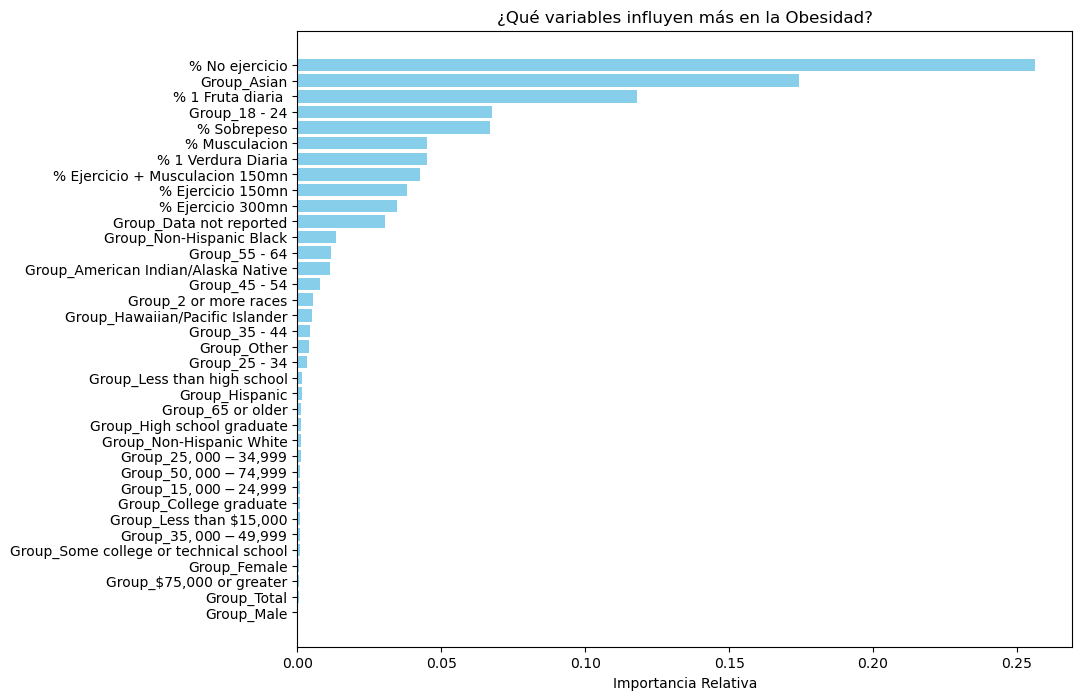

In [308]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Obtener las importancias del modelo
importancias = modelo.feature_importances_
nombres_columnas = X.columns

# 2. Crear un DataFrame para visualizar mejor
df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True)

# 3. Graficar
plt.figure(figsize=(10, 8))
plt.barh(df_importancia['Variable'], df_importancia['Importancia'], color='skyblue')
plt.xlabel('Importancia Relativa')
plt.title('¿Qué variables influyen más en la Obesidad?')
plt.show()